# YOLO on Glass Fibre Dataset

This notebook sets up two YOLO workflows on the glass-fibre tomography data:

- **(a) Object Detection** — bounding-box detection of fibres  
- **(b) Instance Segmentation** — pixel-level fibre masks  

It also loads and visualises the mechanical-test data from `glass-fibre/`.

---
## 0 — Imports & paths

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
import cv2
from pathlib import Path
import tempfile

from ultralytics import YOLO

miopen_dir = tempfile.mkdtemp(prefix="miopen-", dir="/tmp")
os.environ["MIOPEN_USER_DB_PATH"] = miopen_dir
os.environ["MIOPEN_CUSTOM_CACHE_DIR"] = miopen_dir

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# ── project paths ──────────────────────────────────────────────
PROJECT_ROOT = Path('/pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001')                      # ai-tomo root
GLASS_FIBRE  = PROJECT_ROOT / 'glass-fibre'   # mechanical data
DATA_DIR     = PROJECT_ROOT / 'glass-fibres'   # YOLO images+labels
TRAIN_DIR    = DATA_DIR / 'train'
VAL_DIR      = DATA_DIR / 'val'

print(f'Glass-fibre sub-dirs : {sorted([d.name for d in GLASS_FIBRE.iterdir() if d.is_dir()])}')
print(f'Train images         : {len(list(TRAIN_DIR.glob("*.tiff")))}')
print(f'Val   images         : {len(list(VAL_DIR.glob("*.tiff")))}')

Glass-fibre sub-dirs : ['34-700', 'HS40', 'HYBON 2026', 'T300', 'T700']
Train images         : 501
Val   images         : 51


---
## 1 — Explore the Glass-Fibre Mechanical Data

In [2]:
# Load analysed data for every fibre type
fibre_types = sorted([d.name for d in GLASS_FIBRE.iterdir() if d.is_dir()])

analysed = {}
for ft in fibre_types:
    dat_file = list((GLASS_FIBRE / ft).glob('*analysed_data.dat'))[0]
    df = pd.read_csv(dat_file, skipinitialspace=True)
    df['Fibre Type'] = ft
    analysed[ft] = df

df_all = pd.concat(analysed.values(), ignore_index=True)
print(f'Total specimens: {len(df_all)}')
df_all.head()

Total specimens: 695


,Specimen Index,Diameter [um],Gauge length [mm],Load drops [1/0],Strength [MPa],Tensile modulus [GPa],Stiffening rate [GPa/%],Initial tensile modulus [GPa],Unnamed: 8,Fibre Type
0,1.0,6.21,12.271,0.0,5556.624306,254.383775,53.464995,234.643214,NaN,34-700
1,2.0,6.37,12.317,0.0,3231.978616,250.637551,65.247520,227.049590,NaN,34-700
2,3.0,6.42,12.299,0.0,5090.931692,256.493143,60.221147,240.109241,NaN,34-700
3,4.0,7.00,12.244,0.0,3798.931050,227.036568,41.291388,214.271020,NaN,34-700
4,5.0,6.19,12.227,0.0,4157.058444,254.179755,66.730266,229.589812,NaN,34-700


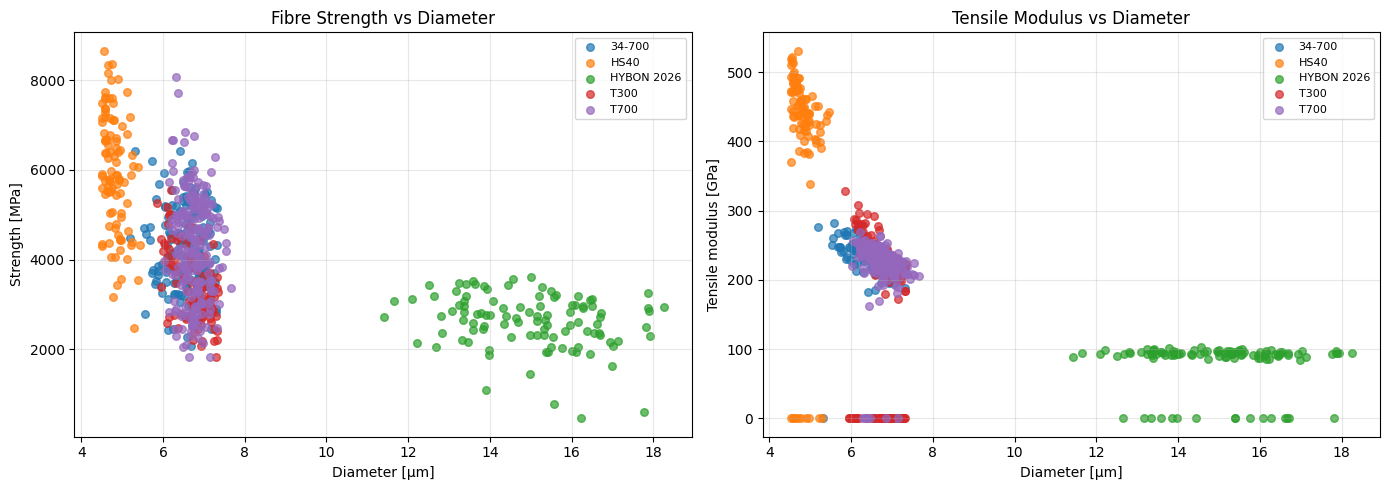

In [3]:
# Compare fibre types: Strength & Tensile Modulus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ft in fibre_types:
    sub = df_all[df_all['Fibre Type'] == ft]
    axes[0].scatter(sub['Diameter [um]'], sub['Strength [MPa]'], label=ft, alpha=0.7, s=30)
    axes[1].scatter(sub['Diameter [um]'], sub['Tensile modulus [GPa]'], label=ft, alpha=0.7, s=30)

axes[0].set(xlabel='Diameter [µm]', ylabel='Strength [MPa]', title='Fibre Strength vs Diameter')
axes[1].set(xlabel='Diameter [µm]', ylabel='Tensile modulus [GPa]', title='Tensile Modulus vs Diameter')
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

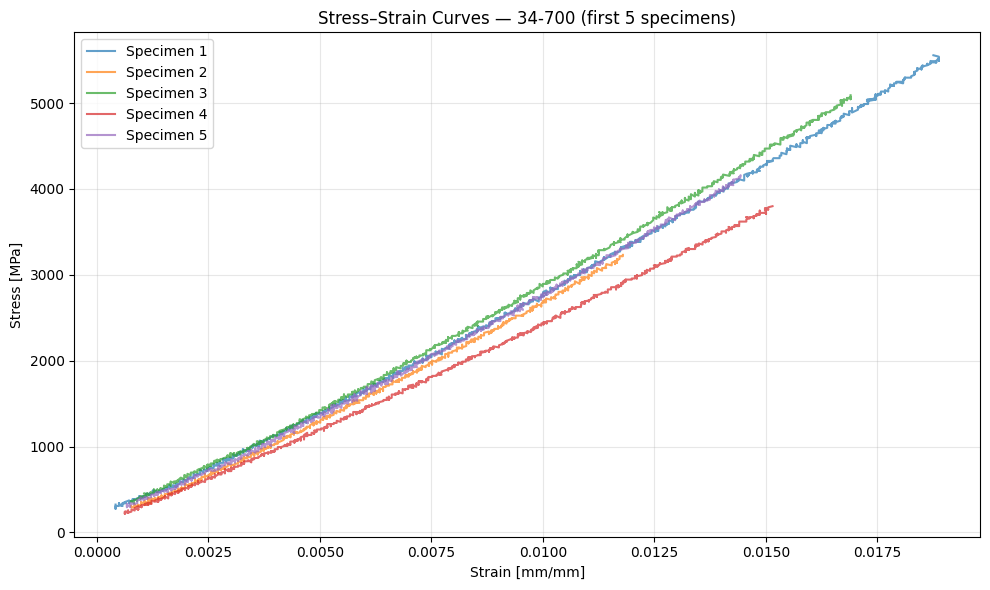

In [4]:
# Load and plot stress-strain curves for one fibre type
ft_example = fibre_types[0]
ss_file = list((GLASS_FIBRE / ft_example).glob('*stress_strain.dat'))[0]
df_ss = pd.read_csv(ss_file, skipinitialspace=True)
# First column is empty due to leading comma — drop it
df_ss = df_ss.iloc[:, 1:]
df_ss.columns = [c.strip() for c in df_ss.columns]

fig, ax = plt.subplots(figsize=(10, 6))
for idx in df_ss['Specimen Index'].unique()[:5]:
    sub = df_ss[df_ss['Specimen Index'] == idx]
    ax.plot(sub['Strain [mm/mm]'], sub['Stress [MPa]'], label=f'Specimen {int(idx)}', alpha=0.7)

ax.set(xlabel='Strain [mm/mm]', ylabel='Stress [MPa]',
       title=f'Stress–Strain Curves — {ft_example} (first 5 specimens)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2 — Inspect the Tomography Image Dataset

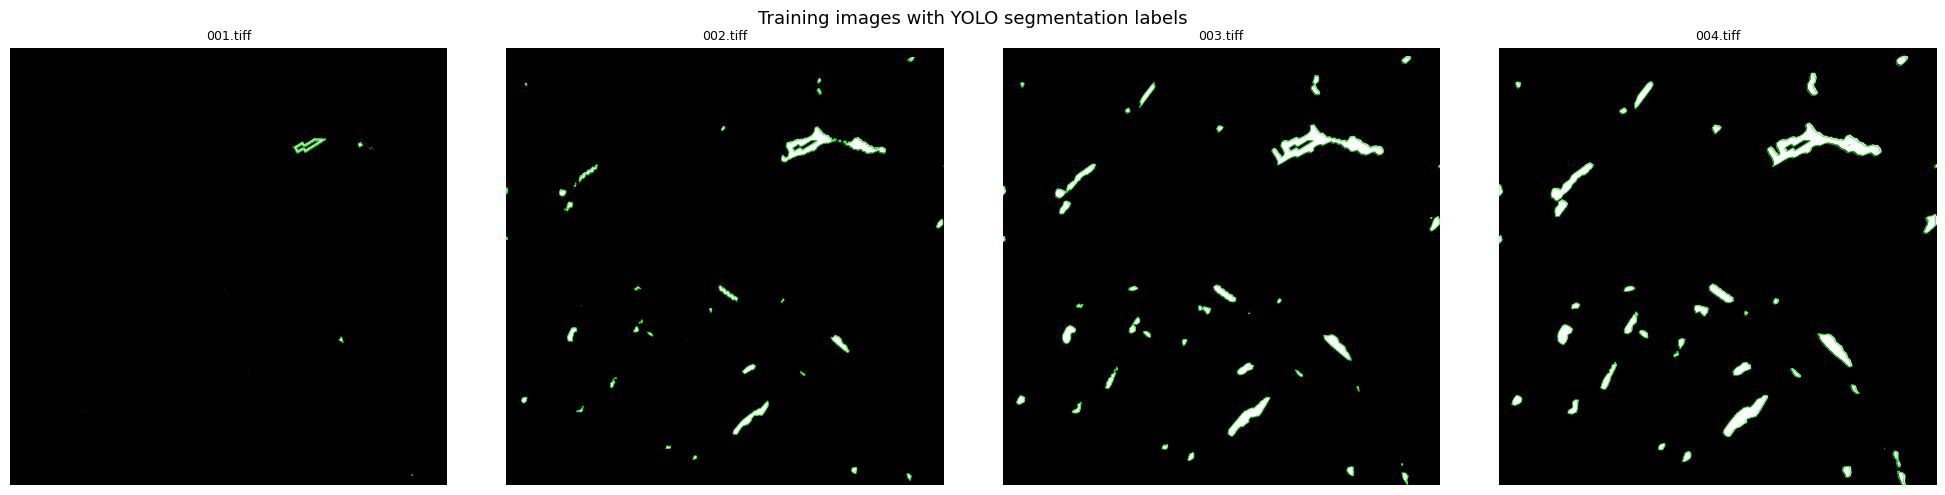

In [5]:
# Show a few training images with their YOLO labels overlaid
train_images = sorted(TRAIN_DIR.glob('*.tiff'))[:4]

fig, axes = plt.subplots(1, len(train_images), figsize=(5 * len(train_images), 5))
if len(train_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, train_images):
    img = io.imread(img_path)
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))  # CHW → HWC
    ax.imshow(img, cmap='gray')

    # Overlay YOLO polygon labels if present
    label_path = img_path.with_suffix('.txt')
    if label_path.exists():
        H = img.shape[0] if img.ndim == 2 else img.shape[0]
        W = img.shape[1] if img.ndim == 2 else img.shape[1]
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                coords = np.array([float(v) for v in parts[1:]]).reshape(-1, 2)
                coords[:, 0] *= W
                coords[:, 1] *= H
                poly = plt.Polygon(coords, fill=False, edgecolor='lime', linewidth=0.5)
                ax.add_patch(poly)

    ax.set_title(img_path.name, fontsize=9)
    ax.axis('off')

plt.suptitle('Training images with YOLO segmentation labels', fontsize=13)
plt.tight_layout()
plt.show()

---
## 3 — Dataset YAML Configuration

In [6]:
import yaml

# ── Detection config ───────────────────────────────────────────
det_yaml = {
    'path': str(DATA_DIR.resolve()),
    'train': 'train',
    'val':   'val',
    'names': {0: 'fiber'},
}

det_yaml_path = PROJECT_ROOT / 'glass-fibre-detect.yaml'
with open(det_yaml_path, 'w') as f:
    yaml.dump(det_yaml, f, default_flow_style=False)

# ── Segmentation config (same data, YOLO uses polygon labels) ─
seg_yaml_path = PROJECT_ROOT / 'glass-fibre-segment.yaml'
with open(seg_yaml_path, 'w') as f:
    yaml.dump(det_yaml, f, default_flow_style=False)   # same content; the task flag decides detect vs segment

print('Detection YAML  :', det_yaml_path)
print('Segmentation YAML:', seg_yaml_path)
print()
print(yaml.dump(det_yaml, default_flow_style=False))

Detection YAML  : /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibre-detect.yaml
Segmentation YAML: /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibre-segment.yaml

names:
  0: fiber
path: /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibres
train: train
val: val



---
## 4(a) — YOLO Object Detection (bounding boxes)

Uses `yolo11n.pt` (a detection-only pretrained model).  
YOLO automatically converts polygon labels to bounding boxes when the task is `detect`.

In [7]:
# Load the detection model
det_model = YOLO('yolo11n.pt')   # pretrained COCO detection weights
print(det_model.info())

YOLO11n summary: 181 layers, 2,624,080 parameters, 0 gradients, 6.6 GFLOPs
(181, 2624080, 0, 6.614336)


In [8]:
# ── Train detection ────────────────────────────────────────────
#   Adjust epochs, imgsz, batch as needed.
#   Set device='cpu' if no GPU is available.

det_results = det_model.train(
    data   = str(det_yaml_path),
    epochs = 30,
    imgsz  = 640,
    batch  = 16,
    name   = 'glass-fibre-detect',
    project = 'runs',
    patience = 10,
    pretrained = True,
    verbose = True,
)

New https://pypi.org/project/ultralytics/8.4.170 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibre-detect.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

In [9]:
# ── Evaluate detection on the validation set ───────────────────
det_metrics = det_model.val(data=str(det_yaml_path))

print(f"mAP@50     : {det_metrics.box.map50:.4f}")
print(f"mAP@50-95  : {det_metrics.box.map:.4f}")
print(f"Precision  : {det_metrics.box.mp:.4f}")
print(f"Recall     : {det_metrics.box.mr:.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7974.2±1500.3 MB/s, size: 2935.8 KB)
val: Scanning /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibres/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 21.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.6s/it 6.4s2.1ss
                   all         51       4089      0.872      0.539      0.582      0.393
Speed: 2.5ms preprocess, 75.9ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to /pfs/lustrep4/users/xieruiwe/YOLO_1001_test/runs/detect/val3
mAP@50     : 0.5820
mAP@50-95  : 0.3927
Precision  : 0.8723
Recall     : 0.5388



0: 640x640 66 fibers, 278.0ms
1: 640x640 64 fibers, 278.0ms
2: 640x640 61 fibers, 278.0ms
3: 640x640 59 fibers, 278.0ms
Speed: 1.8ms preprocess, 278.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)


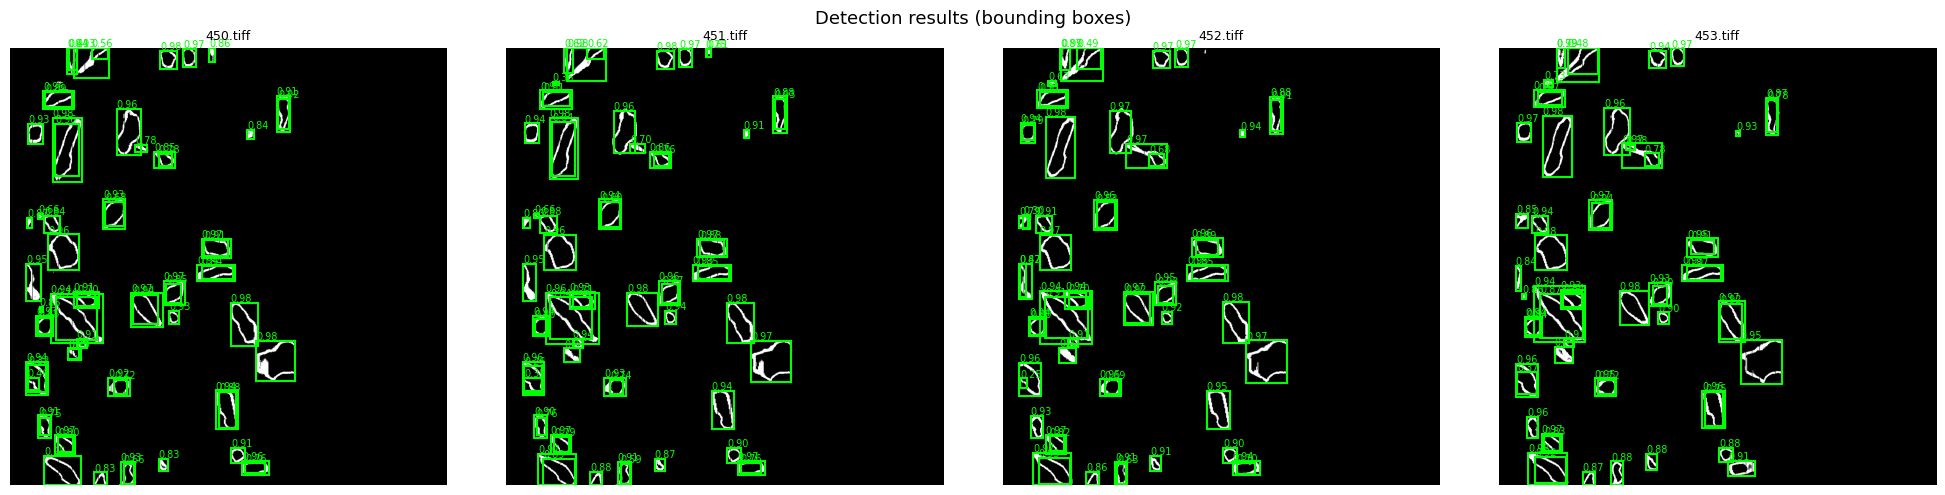

In [10]:
# ── Run detection on sample images ─────────────────────────────
sample_images = sorted(VAL_DIR.glob('*.tiff'))[:4]

det_preds = det_model.predict(
    source = [str(p) for p in sample_images],
    conf   = 0.25,
    save   = False,
)

fig, axes = plt.subplots(1, len(sample_images), figsize=(5 * len(sample_images), 5))
if len(sample_images) == 1:
    axes = [axes]

for ax, result in zip(axes, det_preds):
    img = result.orig_img
    if img.ndim == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img, cmap='gray')

    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = box.conf[0].cpu().item()
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                 fill=False, edgecolor='lime', linewidth=1.5)
            ax.add_patch(rect)
            ax.text(x1, y1 - 2, f'{conf:.2f}', color='lime', fontsize=7)

    ax.set_title(Path(result.path).name, fontsize=9)
    ax.axis('off')

plt.suptitle('Detection results (bounding boxes)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4(b) — YOLO Instance Segmentation (pixel masks)

Uses `yolo11n-seg.pt` (a segmentation pretrained model).  
The polygon labels in the dataset are used directly as segmentation targets.

In [11]:
# Load the segmentation model
seg_model = YOLO('yolo11n-seg.pt')   # pretrained COCO segmentation weights
print(seg_model.info())

YOLO11n-seg summary: 203 layers, 2,876,848 parameters, 0 gradients, 9.9 GFLOPs
(203, 2876848, 0, 9.900352)


In [12]:
# ── Train segmentation ─────────────────────────────────────────
seg_results = seg_model.train(
    data   = str(seg_yaml_path),
    epochs = 30,
    imgsz  = 640,
    batch  = 16,
    name   = 'glass-fibre-segment',
    project = 'runs',
    patience = 10,
    pretrained = True,
    verbose = True,
)

New https://pypi.org/project/ultralytics/8.4.170 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibre-segment.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model

In [13]:
# ── Evaluate segmentation on the validation set ────────────────
seg_metrics = seg_model.val(data=str(seg_yaml_path))

print('=== Box metrics ===')
print(f"  mAP@50     : {seg_metrics.box.map50:.4f}")
print(f"  mAP@50-95  : {seg_metrics.box.map:.4f}")
print()
print('=== Mask metrics ===')
print(f"  mAP@50     : {seg_metrics.seg.map50:.4f}")
print(f"  mAP@50-95  : {seg_metrics.seg.map:.4f}")

Ultralytics 8.4.7 🚀 Python-3.12.3 torch-2.9.1+rocm6.4 CUDA:0 (AMD Instinct MI250X, 65520MiB)
YOLO11n-seg summary (fused): 114 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 9067.3±1667.0 MB/s, size: 2935.8 KB)
val: Scanning /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibres/val.cache... 51 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 51/51 23.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1it/s 3.7s1.1ss
                   all         51       4089      0.865      0.543      0.596      0.393      0.642      0.404      0.385      0.159
Speed: 2.2ms preprocess, 39.6ms inference, 0.0ms loss, 7.3ms postprocess per image
Results saved to /pfs/lustrep4/users/xieruiwe/YOLO_1001_test/runs/segment/val4
=== Box metrics ===
  mAP@50     : 0.5962
  mAP@50-95  : 0.3932



0: 640x640 68 fibers, 143.8ms
1: 640x640 65 fibers, 143.8ms
2: 640x640 65 fibers, 143.8ms
3: 640x640 67 fibers, 143.8ms
Speed: 1.5ms preprocess, 143.8ms inference, 3.0ms postprocess per image at shape (1, 3, 640, 640)


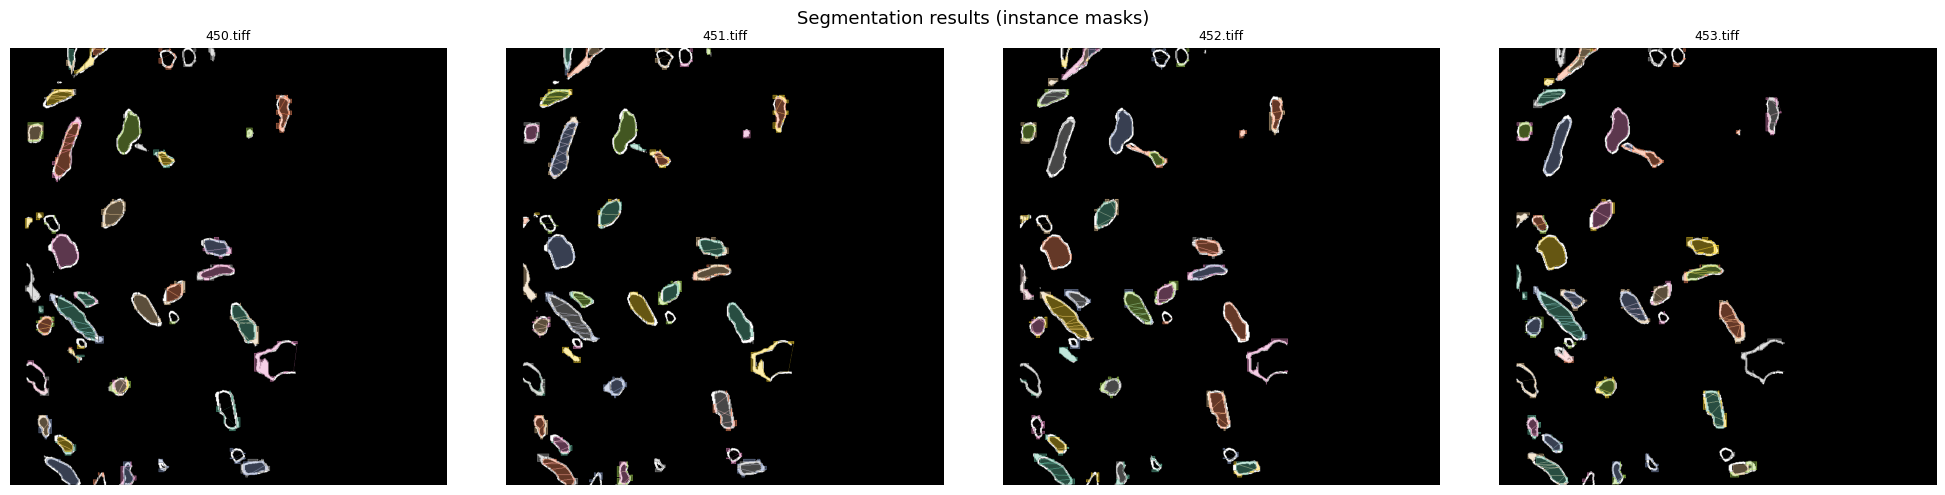

In [14]:
# ── Run segmentation on sample images ──────────────────────────
seg_preds = seg_model.predict(
    source = [str(p) for p in sample_images],
    conf   = 0.25,
    save   = False,
)

fig, axes = plt.subplots(1, len(sample_images), figsize=(5 * len(sample_images), 5))
if len(sample_images) == 1:
    axes = [axes]

colors = plt.cm.Set2(np.linspace(0, 1, 8))

for ax, result in zip(axes, seg_preds):
    img = result.orig_img
    if img.ndim == 3 and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img, cmap='gray')

    # Overlay masks
    if result.masks is not None:
        overlay = np.zeros((*img.shape[:2], 4), dtype=np.float32)
        for i, mask_xy in enumerate(result.masks.xy):
            contour = np.array(mask_xy, dtype=np.int32).reshape((-1, 1, 2))
            c = colors[i % len(colors)]
            tmp = np.zeros((*img.shape[:2], 4), dtype=np.float32)
            cv2.drawContours(tmp, [contour], -1, (*c[:3], 0.4), cv2.FILLED)
            cv2.drawContours(tmp, [contour], -1, (*c[:3], 1.0), 1)
            overlay = np.maximum(overlay, tmp)
        ax.imshow(overlay)

    ax.set_title(Path(result.path).name, fontsize=9)
    ax.axis('off')

plt.suptitle('Segmentation results (instance masks)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5 — Compare Detection vs Segmentation


image 1/1 /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibres/val/450.tiff: 640x640 66 fibers, 11.3ms
Speed: 1.9ms preprocess, 11.3ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /pfs/lustrep4/projappl/project_465002387/DEEP_Inspection_Material_Science/YOLO_1001/glass-fibres/val/450.tiff: 640x640 68 fibers, 10.1ms
Speed: 1.6ms preprocess, 10.1ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


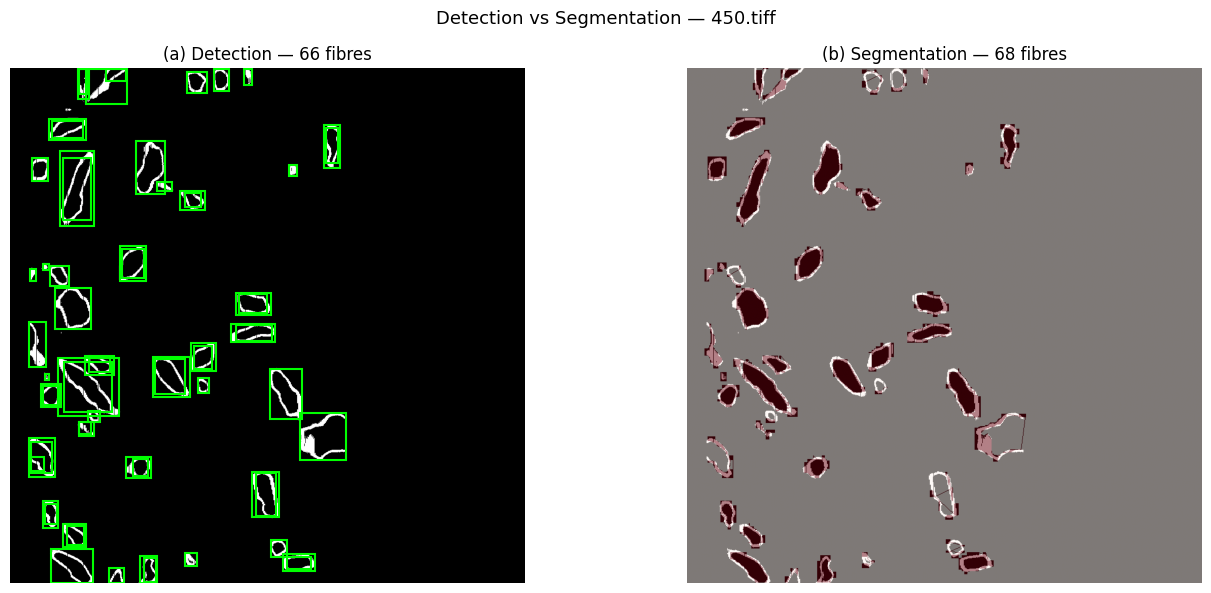

In [15]:
# Side-by-side comparison on a single image
test_img = sorted(VAL_DIR.glob('*.tiff'))[0]

det_r = det_model.predict(str(test_img), conf=0.25, save=False)[0]
seg_r = seg_model.predict(str(test_img), conf=0.25, save=False)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Detection ──
img_det = det_r.orig_img.copy()
if img_det.ndim == 3 and img_det.shape[2] == 3:
    img_det = cv2.cvtColor(img_det, cv2.COLOR_BGR2RGB)
ax1.imshow(img_det, cmap='gray')
if det_r.boxes is not None:
    for box in det_r.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                             fill=False, edgecolor='lime', linewidth=1.5)
        ax1.add_patch(rect)
ax1.set_title(f'(a) Detection — {len(det_r.boxes) if det_r.boxes is not None else 0} fibres')
ax1.axis('off')

# ── Segmentation ──
img_seg = seg_r.orig_img.copy()
if img_seg.ndim == 3 and img_seg.shape[2] == 3:
    img_seg = cv2.cvtColor(img_seg, cv2.COLOR_BGR2RGB)
ax2.imshow(img_seg, cmap='gray')
if seg_r.masks is not None:
    mask_combined = np.zeros(img_seg.shape[:2], dtype=np.float32)
    for mask_xy in seg_r.masks.xy:
        contour = np.array(mask_xy, dtype=np.int32).reshape((-1, 1, 2))
        cv2.drawContours(mask_combined, [contour], -1, 1.0, cv2.FILLED)
    ax2.imshow(mask_combined, cmap='Reds', alpha=0.5)
n_masks = len(seg_r.masks.xy) if seg_r.masks is not None else 0
ax2.set_title(f'(b) Segmentation — {n_masks} fibres')
ax2.axis('off')

plt.suptitle(f'Detection vs Segmentation — {test_img.name}', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6 — Export & Reload Best Weights

After training, the best weights are saved under `runs/`.  
Use the cells below to reload a trained model for inference.

In [16]:
# ── Reload detection model ─────────────────────────────────────
# det_best = YOLO('runs/glass-fibre-detect/weights/best.pt')

# ── Reload segmentation model ──────────────────────────────────
# seg_best = YOLO('runs/glass-fibre-segment/weights/best.pt')

# ── Or use the previously trained segmentation model ───────────
# seg_prev = YOLO('runs/segment/train14/weights/best.pt')

print('Uncomment the model you want to reload.')

Uncomment the model you want to reload.


In [17]:
# ── Export to ONNX (optional) ──────────────────────────────────
# det_model.export(format='onnx', imgsz=640)
# seg_model.export(format='onnx', imgsz=640)

print('Uncomment to export models.')

Uncomment to export models.
